In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense

from utils import load_images, load_labels

SEED = 143


# Loading Data

In [25]:

x_train = load_images('MNSIT Dataset/train-images.idx3-ubyte')
x_test = load_images('MNSIT Dataset/t10k-images.idx3-ubyte')
y_train = load_labels('MNSIT Dataset/train-labels.idx1-ubyte')
y_test = load_labels('MNSIT Dataset/t10k-labels.idx1-ubyte')

# Checking Data

In [26]:
print(x_train.shape)
print(y_train.shape)

print(x_train.dtype)
print(y_train.dtype)

print(x_train.min())
print(x_train.max())

print(np.unique(y_train))

print(np.isnan(x_train).any())

(60000, 28, 28)
(60000,)
uint8
uint8
0
255
[0 1 2 3 4 5 6 7 8 9]
False


# Visualizing Data

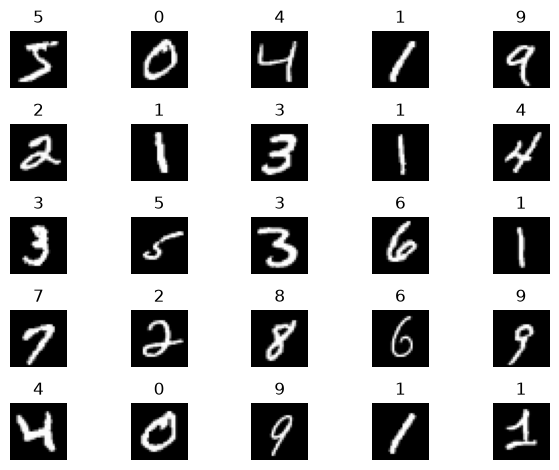

In [27]:
fig, axes = plt.subplots(5, 5)

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(int(y_train[i]))
    ax.axis('off')
    
plt.tight_layout()
plt.show()


# Scaling Model 

In [28]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

# x_train_scaled = x_train_flat.astype("float32") / 255.0
# x_test_scaled = x_test_flat.astype("float32") / 255.0

In [29]:
# len_labels = len(np.unique(y_train))

# tf.random.set_seed(SEED)
# model = tf.keras.models.Sequential([
    
#     tf.keras.Input(shape=(x_test_scaled.shape[1],)),

#     Dense(128, activation='relu', name='L1'),
#     Dense(64, activation='relu', name='L2'),
#     Dense(len_labels, activation='linear', name='L3'),
# ])

model = tf.keras.models.load_model("Models/pro1_valloss_0.08.keras")

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

# Fitting and Compiling

In [30]:
# model.compile(
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     optimizer = tf.keras.optimizers.Adam(0.01)
# )

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=4,
#     restore_best_weights=True,
# )


# history = model.fit(
#     x_train_scaled, y_train,
#     validation_data=[x_test_scaled, y_test],
#     epochs=50,
#     callbacks=[early_stopping]
# )

In [31]:
y_pred_train = model.predict(x_train_scaled)

   8/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step   

W0000 00:00:1786729677.509869    1621 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


In [32]:
y_pred_train = tf.nn.softmax(y_pred_train)
y_pred_train = tf.argmax(y_pred_train, axis=1).numpy()

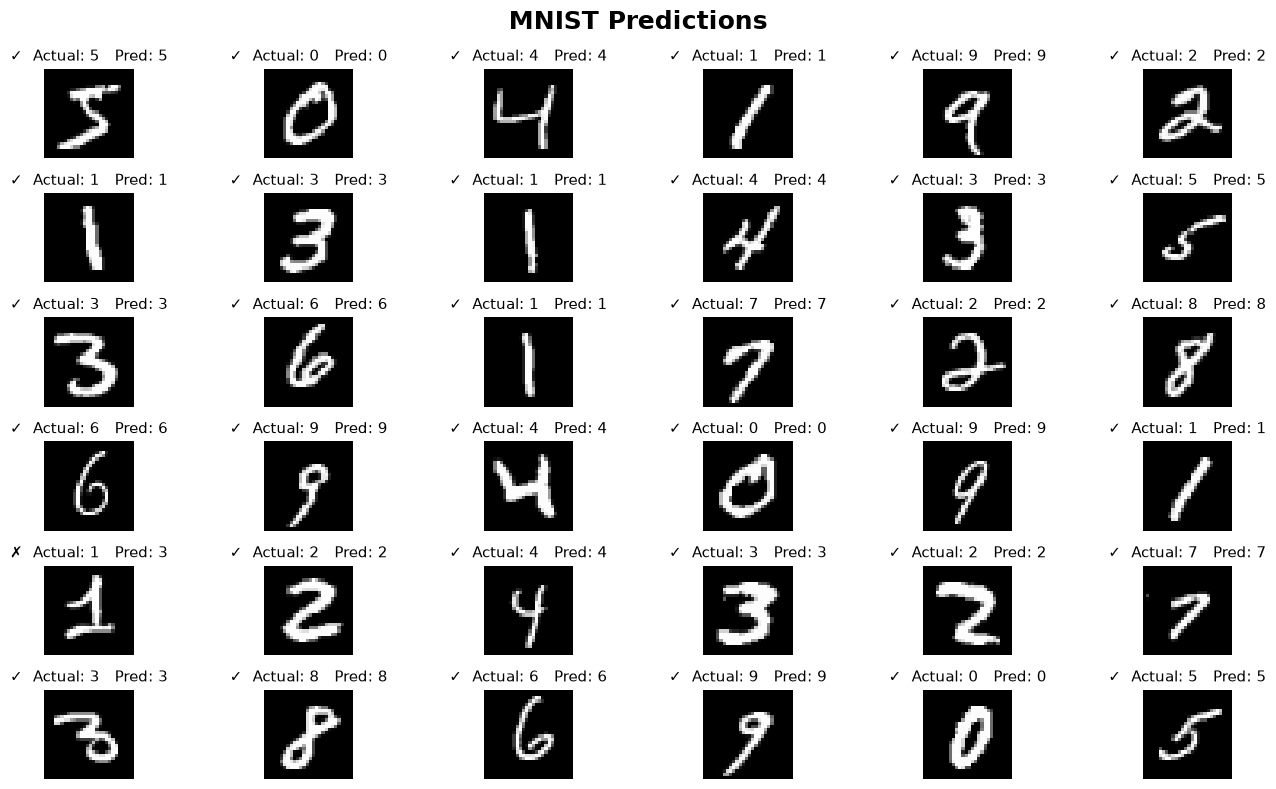

In [53]:
fig, axes = plt.subplots(6, 6, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')

    actual = y_train[i]
    predicted = y_pred_train[i]

    if actual == predicted:
        title = f"✓  Actual: {actual}   Pred: {predicted}"
        ax.set_title(title, fontsize=11)
    else:
        title = f"✗  Actual: {actual}   Pred: {predicted}"
        ax.set_title(title, fontsize=11)

    ax.axis('off')

fig.suptitle(
    "MNIST Predictions",
    fontsize=18,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()